# CINL Prisma QA

## Introduction

This notebook contains code to calculate images and metrics that can be used for quality assurance of MRI data generated on the Siemens MAGNETOM Prisma at CINL.

Currently, the notebook supports the following protocols:
- fMRI stability using fBIRN phantom

The following protocols will be implemented in the future:
- RF noise
- DWI
- MRS
- coil specific protocols

## Prerequisites

The conda environment for these scripts can be loaded from `environment.yml`, which contains all the required python packages.

Data must be in NIFTI format. Please refer to README.md for details about using heudiconv for conversion.


# Import
First, let's import all of the python modules we will be using in our calculations and the dataset we will be processing.

#TODO Load multiple sessions and plot longitudinal data

In [76]:
import nibabel as nib
import nilearn as nil
import scipy.ndimage as ndi
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

# load proxy images from NIFTI
fates = nib.load('../sub-fbirn/ses-Qa03252024CINL7127/func/sub-fbirn_ses-Qa03252024CINL7127_task-stab_bold.nii.gz')
# request array data from proxy images
fates_data = fates.get_fdata()


# Preliminaries
Now we get some information about the dataset (4D fMRI time series) and set up the region of interest that is in the center of the phantom.

In [77]:
# view header
# fates_header = fates.header
# print(fates_header)

# get the size of each dimension in the data array
x_dim, y_dim, z_dim, t_dim = fates_data.shape

# region of interest
roi_x, roi_y, roi_z = 63, 49, 23
roi_size = 20
half_size = roi_size // 2

# coordinate of center slice is roi_z

# define the bounds of the region of interest and ensure they stay within the image bounds
x_min = max(roi_x - half_size, 0)
x_max = min(roi_x + half_size, x_dim - 1)
y_min = max(roi_y - half_size, 0)
y_max = min(roi_y + half_size, y_dim - 1)
# z_min = max(roi_z - half_size, 0)
# z_max = min(roi_z + half_size, z_dim - 1)


Next, we'll define a function to let us add a box to figures so we can visualize the ROI.

In [78]:
def add_roi_box(ax, x_corner, y_corner, box_size):
    box = patches.Rectangle((x_corner, y_corner), box_size, box_size, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(box)

# Mean signal

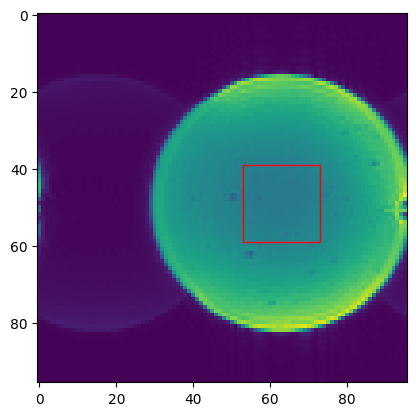

Signal ROI mean = 1556.526734375


In [79]:
# calculate signal image (simple average)
# take center slice only
signal_img = np.mean(fates_data[:,:,roi_z,:], axis=2)
# signal summary value
signal = np.mean(signal_img[x_min:x_max, y_min:y_max])

fig1, ax1 = plt.subplots()
ax1.imshow(signal_img)
add_roi_box(ax1, x_min, y_min, roi_size)
plt.show()

print('Signal ROI mean =', signal)


# Fluctuation noise

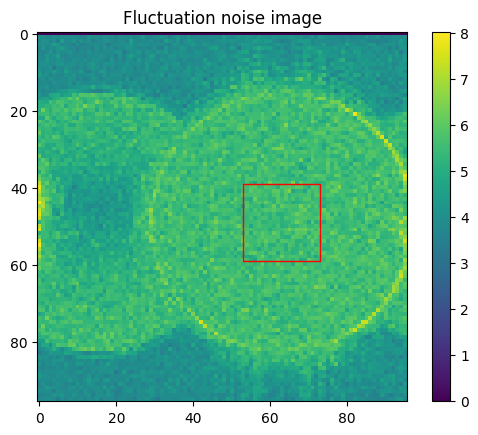

In [81]:
# Initialize an array to store the standard deviation of residuals
fluctuation_noise_img = np.zeros((x_dim, y_dim))

# Loop through each voxel
for i in range(x_dim):
    for j in range(y_dim):
            # Extract the time-series for the current voxel
            time_series = fates_data[i, j, roi_z, :]

            # Fit a second-order polynomial
            time_points = np.arange(t_dim)
            coefficients = np.polyfit(time_points, time_series, 2)
            polynomial = np.poly1d(coefficients)

            # Calculate the residuals (original - fitted)
            fitted_values = polynomial(time_points)
            residuals = time_series - fitted_values

            # Calculate the standard deviation of the residuals
            fluctuation_noise_img[i, j] = np.std(residuals)

# TODO vectorize code for timely 3d calculation
""" # prepare time points (0, 1, ... , T-1)
time_points = np.arange(t_dim)
# generate design matrix for 2nd-order polynomial
# columns for powers x^2, x^1, x^0
X = np.vstack([time_points**2, time_points, np.ones(t_dim)]).T
# reshape data for batch processing
data_transposed = np.transpose(fates_data, (3, 0, 1, 2))
data_reshaped = np.reshape(fates_data, (t_dim, -1))
# perform least squares fit
coefficients, _, _, _ = np.linalg.lstsq(X, data_reshaped, rcond=None)
# calculate fitted values from coefficients
fitted_values = X @ coefficients
# compute residuals
residuals = data_reshaped - fitted_values
# calculate standard deviation of residuals along time axis
residuals_std = np.std(residuals, axis=0)
# reshape to original spatial dimensions
fluct_noise_img = np.reshape(residuals_std, (x_dim, y_dim, z_dim)) """

plt.imshow(fluctuation_noise_img)
ax2 = plt.gca()
plt.title('Fluctuation noise image')
plt.colorbar()
add_roi_box(ax2, x_min, y_min, roi_size)
plt.show()

# Signal-to-fluctuation-noise ratio

/var/folders/v_/33wg3kzn5q54tpczjxxwwzdh0000gn/T/ipykernel_8385/2934247358.py:3: RuntimeWarning: invalid value encountered in divide
  sfnr_img = signal_img / fluctuation_noise_img


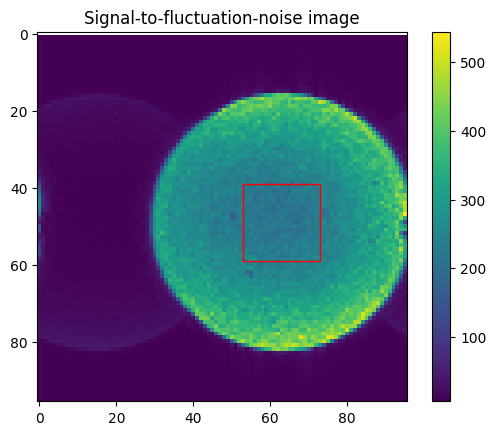

SFNR = 284.1755234632227


In [82]:
# SIGNAL-TO-FLUCTUATION-NOISE RATIO (SFNR) IMAGE
# voxelwise division of signal and temporal fluctuation noise image
sfnr_img = signal_img / fluctuation_noise_img
# summary SFNR value from ROI
sfnr = np.mean(sfnr_img[x_min:x_max, y_min:y_max])

plt.imshow(sfnr_img)
plt.title('Signal-to-fluctuation-noise image')
plt.colorbar()
ax3 = plt.gca()
add_roi_box(ax3, x_min, y_min, roi_size)
plt.show()

print('SFNR =', sfnr)


# Static spatial noise

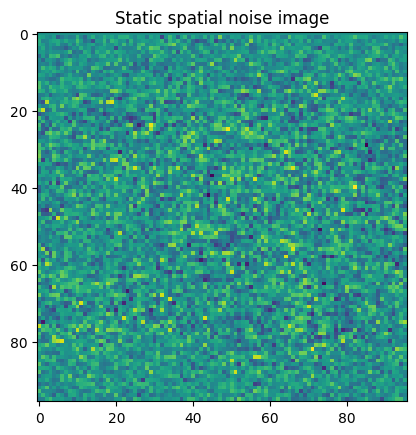

Static spatial noise variance in ROI = 63.0419


In [ ]:
# STATIC SPATIAL NOISE IMAGE
sumEven_img = np.sum(fates_data[:, :, roi_z, 0:2:t_dim], axis=2)
sumOdd_img = np.sum(fates_data[:, :, roi_z, 1:2:t_dim], axis=2)
diff_img = sumOdd_img - sumEven_img
# static spatial noise variance summary value
ssnvar = np.var(diff_img[x_min:x_max, y_min:y_max])

plt.imshow(diff_img)
plt.title('Static spatial noise image')
plt.show()

print('Static spatial noise variance in ROI =', ssnvar)

# Signal-to-noise ratio

In [ ]:
# SNR
snr = signal / np.sqrt(ssnvar)

print('SNR in ROI =', snr)

SNR in ROI = 196.038755797627


# Detrending

In [ ]:
# initialize array to store average roi values
averages = np.zeros(fates_data.shape[3])

# compute average of each time point
for t in range(fates_data.shape[3]):
    region = fates_data[x_min:x_max+1, y_min:y_max+1, roi_z, t]
    averages[t] = np.mean(region)

# mean signal intensity
signal_intensity = np.mean(averages)

# fit polynomal for detrending
time_points = np.arange(len(averages))
degree = 2
coefficients = np.polyfit(time_points, averages, degree)
p = np.poly1d(coefficients)

# evaluate polynomial over time range
t_fit = np.linspace(time_points.min(), time_points.max(), 160)
y_fit = p(t_fit)

# calculate residuals (detrended data)
residuals = averages - y_fit


# Drift

Drift = 0.45205810013482295 %


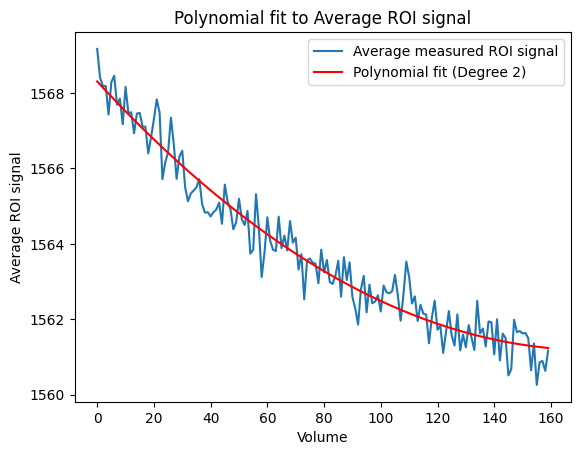

In [ ]:

# Percent drift
percent_drift = (max(y_fit) - min(y_fit)) / signal_intensity * 100

print('Drift =', percent_drift, '%')

plt.figure()
plt.plot(time_points, averages, '-', label='Average measured ROI signal')
plt.plot(t_fit, y_fit, '-', label=f'Polynomial fit (Degree {degree})', color='red')
plt.title('Polynomial fit to Average ROI signal')
plt.xlabel('Volume')
plt.ylabel('Average ROI signal')
plt.legend()


# Fluctuation

Fluctuation = 0.03063028603747979 %


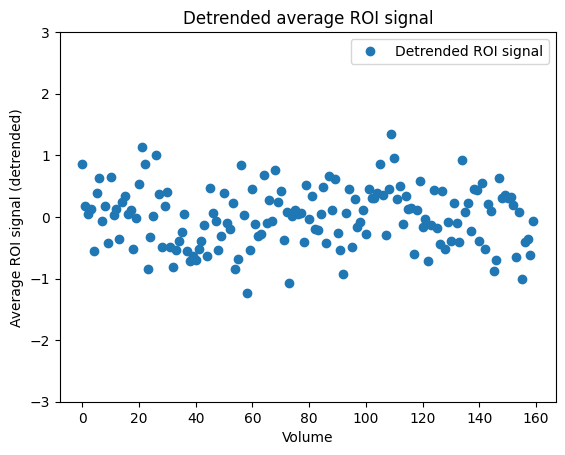

In [ ]:

percent_fluctuation = 100 * np.std(residuals) / signal_intensity

plt.figure()
plt.plot(time_points, residuals, 'o', label='Detrended ROI signal')
plt.title('Detrended average ROI signal')
plt.xlabel('Volume')
plt.ylabel('Average ROI signal (detrended)')
plt.ylim(-3, 3)
plt.legend()

print('Fluctuation =', percent_fluctuation, '%')


# Noise spectrum

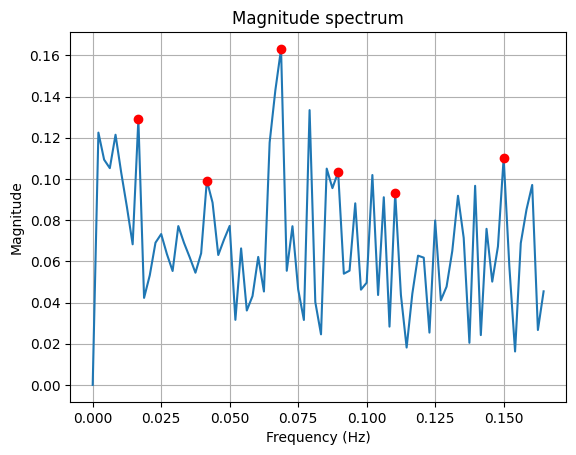

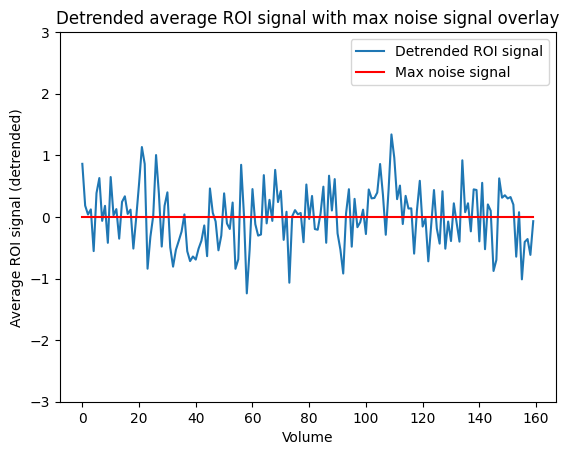

Fitted parameters: [10.  0. 10.  0.  0.]
R-squared: -1.0325074129013956e-13
Debug Values:
tr = 3 s
peak frequency= 0.06875 Hz
Summary Values:
Signal = 1556.526734375
SSN variance = 63.0419
SNR = 196.038755797627
SFNR = 284.1755234632227
Fluctuation = 0.03063028603747979 %
Drift = 0.45205810013482295 %


In [ ]:
# Signal magnitude spectrum
mag_spectrum = fft(residuals)
# sample spacing
tr = 3
x = np.linspace(0.0, t_dim*tr, t_dim, endpoint=False)
xf = fftfreq(t_dim, tr)[:t_dim//2]
yf = np.abs(mag_spectrum[0:t_dim//2])

# find maximum y-value of spectrum
max_index = np.argmax(yf)
xf_max = xf[max_index]

# detect peaks
peaks, properties = find_peaks(yf, height=0, distance = 10)

plt.figure()
plt.plot(xf, 2.0/t_dim * yf, label='spectrum')
plt.plot(xf[peaks], 2.0/t_dim * yf[peaks], 'o', label='detected peaks', color='red')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.title('Magnitude spectrum')

# get indices of sorted peaks array (in descending order)
peak_indices = np.argsort(peaks)[::-1]

# select the indices of the two largest peaks
top_peaks = peak_indices[:2]

# Fit and Plot noise signal at peak frequency
def noise_model(x, A, B, C, D, E, top_peaks):
        return A * np.sin(2.0*np.pi*top_peaks[0]*x + B) + C * np.sin(2.0*np.pi*top_peaks[1]*x + D) + E

# initial guess at parameters
initial_guess = [10, 0, 10, 0, 0]
# ([lower bounds], [upper bounds])
bounds = ([0.1, -np.pi, 0.1, -np.pi, -1], [100, np.pi, 100, np.pi, 1])

# curve fitting
params, params_covariance = curve_fit(lambda x, A, B, C, D, E: noise_model(x, A, B, C, D, E, top_peaks), t_fit, residuals, p0=initial_guess, bounds=bounds)

noise_fit = noise_model(t_fit, *params, top_peaks)
noise_residuals = residuals - noise_fit
ss_tot = np.sum((residuals - np.mean(residuals))**2)
ss_res = np.sum(noise_residuals**2)
r_squared = 1 - (ss_res / ss_tot)

plt.figure()
plt.plot(time_points, residuals, '-', label='Detrended ROI signal')
plt.plot(t_fit, noise_fit, '-', label='Max noise signal', color='red')
plt.title('Detrended average ROI signal with max noise signal overlay')
plt.xlabel('Volume')
plt.ylabel('Average ROI signal (detrended)')
plt.ylim(-3, 3)
plt.legend()

plt.show()

print('Fitted parameters:', params)
print('R-squared:', r_squared)

# PRINT DEBUG VALUES
print('Debug Values:')
print('tr =', tr, 's')
print('peak frequency=', xf_max, 'Hz')

# PRINT SUMMARY VALUES
print('Summary Values:')
print('Signal =', signal)
print('SSN variance =', ssnvar)
print('SNR =', snr)
print('SFNR =', sfnr)
print('Fluctuation =', percent_fluctuation, '%')
print('Drift =', percent_drift, '%')

# visualize raw data
# nib.viewers.OrthoSlicer3D(fates_data).show()

# region of interest
# center of sphere is ~ 63, 49, 23
# check
# intensity = fates_data[49,63,23,0]
# print(intensity)

# plt.imshow(fates_data[:,:,23,0])
# plt.show()